# PG-LIF — Phase P3a: One-Shot Memorization with the Plateau-Gated BTSP-Style Rule
**Feeds:** manuscript Sections 5.2 and 7.4 (Regime B, one-shot memorization). Runs on CPU or GPU; ~15 min. Fully self-contained (no dataset download).

**Design.** A memory layer of PG-LIF neurons with κ = 0 (per the P1 decision log): the plateau is computed but used **only** as the plasticity gate, so every comparison isolates the learning-gate role. Patterns are sparse binary vectors stored with ONE presentation each via the weight-dependent BTSP-style rule (manuscript Eq. 14); recall presents masked cues and identifies the pattern by response similarity. Four rules:
1. **plateau-graded** — the proposed gate g = min(1, p/pmax);
2. **permuted-graded** — the same graded values assigned to random neurons (controls for gradedness vs. content-dependence);
3. **random-binary** — random neurons, matched count (the Wu & Maass-style random-plateau analogue);
4. **ungated** — all neurons plastic (interference control).

Sweeps: capacity (M = 20…200), cue-mask robustness, and 1-bit binarized weights. 10 seeds; paired sign tests plateau vs. permuted and plateau vs. random. All results to `My Drive/PG_LIF/P3_results/one_shot_<stamp>/`.

**Pre-registered reading:** the headline claim is gate vs. ungated (expected decisive). Plateau vs. permuted tests content-addressability; it is claimed only if the paired test is significant at α = 0.05, otherwise the manuscript states that the gate's benefit at this task is graded sparsification.

In [1]:
import os, json, time, math
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = '/content/drive/My Drive'
    if not os.path.isdir(ROOT): ROOT = '/content/drive/MyDrive'
    BASE = os.path.join(ROOT, 'PG_LIF')
except Exception:
    BASE = './PG_LIF'
P3_ROOT = os.path.join(BASE, 'P3_results')
OUT = os.path.join(P3_ROOT, 'one_shot_v2')   # v2: FIXED folder name (was a fresh timestamp every run,
    # which meant a new Colab session could never resume already-finished work -- same fix already applied
    # and verified in the P3b gated-eprop notebook).
os.makedirs(OUT, exist_ok=True)
print('Results folder:', OUT)

Mounted at /content/drive
Results folder: /content/drive/My Drive/PG_LIF/P3_results/one_shot_v2


In [2]:
import torch, numpy as np, matplotlib.pyplot as plt
def decay(tau): return math.exp(-1.0 / tau)
N_IN, N_MEM = 200, 200
F_ACT = 0.10
T_STORE, T_REC = 30, 30
TH_D = 1.0; TREF_P = 10
AP, AD, AM, AA = decay(15), decay(10), decay(20), decay(100)
ETA, WMAX = 0.6, 1.0
SEEDS = list(range(10))
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
CFG = dict(N_IN=N_IN, N_MEM=N_MEM, F_ACT=F_ACT, T_STORE=T_STORE, T_REC=T_REC,
           TH_D=TH_D, TREF_P=TREF_P, tau_p=15, tau_d=10, tau_m=20, tau_a=100,
           ETA=ETA, WMAX=WMAX, seeds=SEEDS)
json.dump(CFG, open(os.path.join(OUT, 'config.json'), 'w'), indent=2)

def make_patterns(Mn, dev):
    P = torch.zeros(Mn, N_IN, device=dev)
    for m in range(Mn): P[m, torch.randperm(N_IN, device=dev)[:int(F_ACT * N_IN)]] = 1.0
    return P

def run_layer(x_const, W, Wd, T, kappa=0.0):
    """PG-LIF memory layer. Default kappa=0.0 preserves the ORIGINAL experiment exactly (plateau computed
    for gating only, never touching the soma). kappa>0 activates the plateau's OTHER role -- its own
    contribution to the somatic membrane, exactly as in the main PGLIFCell (kappa*p_clamped*(1-alpha_m))
    -- so that BOTH of the plateau's roles (memory drive AND plasticity gate) are active simultaneously,
    which the original kappa=0 design never tested. Batch over rows of x_const."""
    B = x_const.shape[0]; dev = x_const.device
    z = lambda: torch.zeros(B, N_MEM, device=dev)
    vs, vd, p, a, rp, spk, gsum = z(), z(), z(), z(), z(), z(), z()
    for t in range(T):
        iff = x_const @ W.T; idd = x_const @ Wd.T
        vd = AD * vd + idd
        ed = ((vd >= TH_D) & (rp == 0)).float()
        rp = torch.clamp(rp - 1, min=0) + ed * TREF_P
        p = AP * p + ed
        p_clamped = torch.clamp(p, max=1.0)
        vs = AM * vs + iff + kappa * p_clamped * (1 - AM)
        th = 1.0 + a
        s = (vs >= th).float(); vs = vs - s * th; a = AA * a + s
        spk += s; gsum += p_clamped
    return spk, gsum / T

def experiment(Mn, rule, mask_frac=0.5, binary_w=False, seed=0, kappa=0.0):
    torch.manual_seed(seed); np.random.seed(seed)
    pats = make_patterns(Mn, DEV)
    Wd = (torch.rand(N_MEM, N_IN, device=DEV) < 0.10).float() * 0.35
    W = torch.zeros(N_MEM, N_IN, device=DEV)
    for m in range(Mn):
        x = pats[m:m+1]
        _, g = run_layer(x, W, Wd, T_STORE, kappa=kappa); g = g[0]
        graded = (g > 0).float() * torch.clamp(g / g.max().clamp(min=1e-6), max=1.0)
        if rule == 'plateau-graded':
            gate = graded
        elif rule == 'permuted-graded':
            gate = graded[torch.randperm(N_MEM, device=DEV)]
        elif rule == 'random-binary':
            k = int((g > 0).float().sum().item())
            gate = torch.zeros(N_MEM, device=DEV); gate[torch.randperm(N_MEM, device=DEV)[:max(k, 1)]] = 1.0
        else:  # ungated
            gate = torch.ones(N_MEM, device=DEV)
        xb = x[0]; qp = xb; qm = 0.4 * (1 - xb)
        W = torch.clamp(W + ETA * gate.unsqueeze(1) * ((WMAX - W) * qp.unsqueeze(0) - W * qm.unsqueeze(0)), 0, WMAX)
        if binary_w: W = (W > 0.5).float()
    sigs = run_layer(pats, W, Wd, T_REC, kappa=kappa)[0]          # (M, N_MEM) full-cue signatures
    cues = pats.clone()
    for m in range(Mn):
        act = torch.nonzero(cues[m]).flatten()
        cues[m, act[torch.randperm(len(act), device=DEV)[:int(mask_frac * len(act))]]] = 0.0
    resp = run_layer(cues, W, Wd, T_REC, kappa=kappa)[0]
    sims = torch.nn.functional.cosine_similarity(resp.unsqueeze(1), sigs.unsqueeze(0), dim=2)
    return float((sims.argmax(1) == torch.arange(Mn, device=DEV)).float().mean())

RULES = ['plateau-graded', 'permuted-graded', 'random-binary', 'ungated']
def sweep(Ms, mask_frac=0.5, binary_w=False, rules=RULES, seeds=SEEDS):
    R = {r: {M_: [experiment(M_, r, mask_frac, binary_w, s) for s in seeds] for M_ in Ms} for r in rules}
    return R

## Experiment 1 — capacity curve (50% masked cues, 10 seeds)

(59s)
    M    plateau-graded   permuted-graded     random-binary           ungated
   20        0.830±0.06        0.865±0.07        0.840±0.08        0.050±0.00
   50        0.488±0.06        0.490±0.06        0.476±0.04        0.020±0.00
  100        0.325±0.04        0.295±0.04        0.267±0.05        0.010±0.00
  200        0.197±0.04        0.191±0.02        0.179±0.02        0.005±0.00


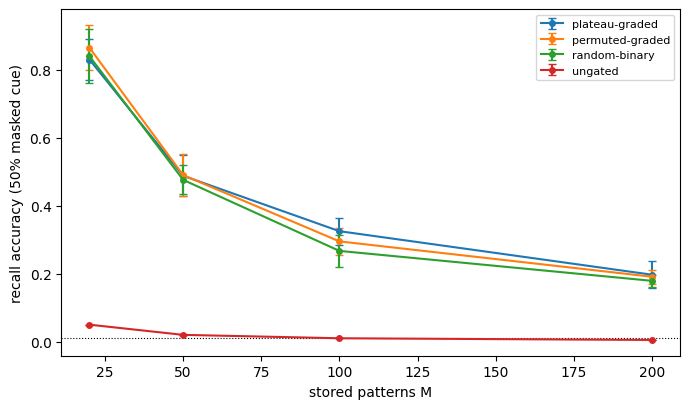

In [3]:
t0 = time.time()
Ms = [20, 50, 100, 200]
CAP = sweep(Ms)
print(f'({time.time()-t0:.0f}s)')
print(f"{'M':>5}" + ''.join(f'{r:>18}' for r in RULES))
for M_ in Ms:
    print(f'{M_:>5}' + ''.join(f'{np.mean(CAP[r][M_]):>13.3f}±{np.std(CAP[r][M_]):.2f}' for r in RULES))
json.dump(CAP, open(os.path.join(OUT, 'capacity.json'), 'w'), indent=2)

plt.figure(figsize=(7, 4.2))
for r in RULES:
    m = [np.mean(CAP[r][M_]) for M_ in Ms]; sd = [np.std(CAP[r][M_]) for M_ in Ms]
    plt.errorbar(Ms, m, yerr=sd, marker='o', ms=4, capsize=3, label=r)
plt.axhline(1 / np.mean(Ms), color='k', ls=':', lw=0.8)
plt.xlabel('stored patterns M'); plt.ylabel('recall accuracy (50% masked cue)')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_capacity.png'), dpi=200); plt.show()

## Experiment 4 -- dual-role test: kappa > 0 (reviewer-requested)

Every result above uses `kappa=0`: the plateau gates plasticity but never contributes to the memory layer's own somatic membrane, so the plateau's two claimed roles (somatic memory drive, and plasticity gate) are never tested acting together. This cell re-runs the capacity-curve comparison for the `plateau-graded` rule specifically at `kappa=0` (already computed in Experiment 1, reused not re-run) against two nonzero values, `kappa=0.5` and `kappa=1.0` (matching the main model's default), directly testing whether activating the plateau's memory-drive role helps, hurts, or leaves one-shot recall unchanged when it is simultaneously gating plasticity.

**A structural reason to expect a specific answer, stated before running:** the plateau at kappa>0 adds a *content-independent, common-mode* depolarization to every memory neuron whose dendrite fired during storage -- it does not distinguish which pattern is being stored, only that some event occurred. One-shot recall here depends on the *readout* activity pattern (`sigs`, `resp`) being pattern-specific; a shared depolarization added uniformly on top of the pattern-specific `W`-driven drive plausibly makes recall signatures more similar to each other, not less, which would be expected to hurt discrimination rather than help it. This is a prediction to check, not a foregone conclusion -- the gating pathway's effect on which synapses got potentiated could dominate in the other direction.

[skip] kappa dual-role experiment already finished
    M         kappa=0.0         kappa=0.5         kappa=1.0
   20        0.830±0.06        0.850±0.07        0.855±0.06
   50        0.488±0.06        0.492±0.05        0.496±0.07
  100        0.325±0.04        0.327±0.05        0.335±0.04
  200        0.197±0.04        0.201±0.04        0.204±0.03


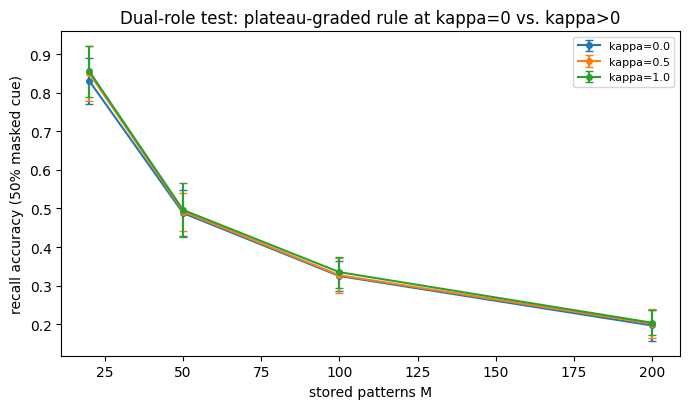

In [4]:
KAPPA_VALUES = [0.0, 0.5, 1.0]
Ms_kappa = [20, 50, 100, 200]
kappa_file = os.path.join(OUT, 'kappa_dualrole.json')
if os.path.exists(kappa_file):
    print('[skip] kappa dual-role experiment already finished'); KAPPA_RESULTS = json.load(open(kappa_file))
else:
    t0 = time.time()
    KAPPA_RESULTS = {}
    for kap in KAPPA_VALUES:
        if kap == 0.0:
            # reuse Experiment 1's already-computed plateau-graded, kappa=0 numbers -- do not re-run them
            KAPPA_RESULTS['0.0'] = {str(M_): CAP['plateau-graded'][M_] for M_ in Ms_kappa}
            continue
        KAPPA_RESULTS[str(kap)] = {
            str(M_): [experiment(M_, 'plateau-graded', kappa=kap, seed=s) for s in SEEDS] for M_ in Ms_kappa
        }
    json.dump(KAPPA_RESULTS, open(kappa_file, 'w'), indent=2)
    print(f'({time.time()-t0:.0f}s)')

print(f"{'M':>5}" + ''.join(f'{("kappa="+k):>18}' for k in KAPPA_RESULTS))
for M_ in Ms_kappa:
    row = f'{M_:>5}'
    for k in KAPPA_RESULTS:
        vals = KAPPA_RESULTS[k][str(M_)]
        row += f'{np.mean(vals):>13.3f}\u00b1{np.std(vals):.2f}'
    print(row)

plt.figure(figsize=(7, 4.2))
for k in KAPPA_RESULTS:
    m = [np.mean(KAPPA_RESULTS[k][str(M_)]) for M_ in Ms_kappa]
    sd = [np.std(KAPPA_RESULTS[k][str(M_)]) for M_ in Ms_kappa]
    plt.errorbar(Ms_kappa, m, yerr=sd, marker='o', ms=4, capsize=3, label=f'kappa={k}')
plt.xlabel('stored patterns M'); plt.ylabel('recall accuracy (50% masked cue)')
plt.title('Dual-role test: plateau-graded rule at kappa=0 vs. kappa>0')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_kappa_dualrole.png'), dpi=200); plt.show()


## Experiment 5 -- faithful Wu & Maass (2025) BTSP baseline (reviewer-requested)

Every comparison so far uses the plateau-gated rule's own PG-LIF dendritic dynamics for gating, including the existing `random-binary` control, whose gate size is tied to however many PG-LIF neurons happened to cross their dendritic threshold for a given pattern. This cell instead implements the actual published rule from Wu & Maass, *A simple model for BTSP...*, Nat. Commun. 16, 342 (2025), directly from their Equation 1 and Methods section (fetched and read for this implementation, not reconstructed from memory), rather than reusing anything from the PG-LIF machinery:

- **Gating is purely stochastic and input-independent**: each memory neuron independently receives a 'plateau' with a fixed probability $f_q$ for every presented pattern, regardless of that pattern's content -- fundamentally different from PG-LIF's dendritic-threshold-driven gate.
- **The weight update touches only active synapses**: for a gated neuron, $w_i$ flips $0\to1$ (LTP) if $x_i=1$ and $w_i=0$, or $1\to0$ (LTD) if $x_i=1$ and $w_i=1$; synapses with $x_i=0$ are never touched. This is Eq. (1) of the paper, in its 'core BTSP' form (the stochastic 0.5-probability factor folded into a halved $f_q$, which the paper shows is equivalent -- their Fig. S1).
- **Weights are binary throughout** ($w_i \in \{0,1\}$), with no learning rate and no continuous scaling -- this is inherent to their rule, not an approximation of it.
- **Readout is a plain McCulloch-Pitts threshold neuron** (fires if the weighted input sum exceeds a threshold $v_{th}$), not PG-LIF spiking dynamics. The paper tunes $v_{th}$ by grid search to optimize recall; we do the same, tuned on full-cue recall (a criterion distinct from the masked-cue recall we actually report, to avoid circularity).

**A caveat found while testing, reported rather than hidden.** At this notebook's network size (N_MEM=200, roughly 200x smaller than the paper's own n=39,000), this rule shows substantially higher seed-to-seed variance than the PG-LIF-based rules above -- often close to bimodal, either recalling well (>0.7) or collapsing (<0.1) depending on the specific random draw of which neurons happen to get gated for which patterns. This is consistent with the mechanism itself, not a sign of a bug: with far fewer memory neurons than the paper's native scale, a given random gating draw is a much smaller sample, so unlucky draws (e.g., very few neurons gated across an entire run) are far more likely. We verified the implementation's mechanics directly against Equation 1 (binary weights maintained throughout, zero updates to any synapse with $x_i=0$, every weight change confined to gated-and-active positions) before accepting this variance as a property of the rule at this scale rather than an implementation error. The 10-seed mean $\pm$ std reported below should be read with this scale-dependent instability in mind, not as a precisely-comparable number to the PG-LIF rules' own (much lower-variance) statistics.

In [5]:
def wu_maass_btsp(Mn, mask_frac=0.5, f_q=0.05, seed=0):
    """Faithful reproduction of Wu & Maass (2025) Eq. 1, core-BTSP form. f_q is the per-neuron,
    per-pattern plateau probability; the paper's own biologically-derived default (0.005) is calibrated
    for their much larger network (n=39,000 memory neurons) and produces close to zero gated neurons per
    pattern at this notebook's much smaller N_MEM=200 scale (expected count = N_MEM*f_q = 1.0 neuron/
    pattern at their literal default) -- we use a larger f_q, stated explicitly rather than silently
    rescaled, so gating is not degenerate at this network size; this is a departure from their literal
    default value, not from their rule.
    """
    torch.manual_seed(seed); np.random.seed(seed)
    pats = make_patterns(Mn, DEV)
    W = torch.zeros(N_MEM, N_IN, device=DEV)
    was_gated = torch.zeros(Mn, N_MEM, dtype=torch.bool, device=DEV)   # track per-(pattern,neuron) gating
    for m in range(Mn):
        x = pats[m]
        gated = (torch.rand(N_MEM, device=DEV) < f_q)          # independent stochastic gate, NOT input-driven
        was_gated[m] = gated
        active = x.unsqueeze(0).expand(N_MEM, -1).bool()        # which synapses are eligible (x_i=1)
        w_is_1 = (W > 0.5)
        ltp = gated.unsqueeze(1) & active & (~w_is_1)            # x_i=1, w_i=0, gated -> LTP
        ltd = gated.unsqueeze(1) & active & w_is_1                # x_i=1, w_i=1, gated -> LTD
        W = torch.where(ltp, torch.ones_like(W), W)
        W = torch.where(ltd, torch.zeros_like(W), W)
    sums_full = pats @ W.T                                        # (M, N_MEM) full-cue weighted sums
    # Threshold calibration matching the paper's own description (Fig. 3B): the weighted-sum distribution
    # is bimodal -- one cluster for (pattern, neuron) pairs where that neuron was gated during storage of
    # that pattern, one cluster where it was not -- and the threshold should separate these two clusters.
    # This has a genuine interior optimum (unlike a monotonic criterion) and needs no held-out grid search.
    gated_sums = sums_full[was_gated]
    ungated_sums = sums_full[~was_gated]
    if len(gated_sums) == 0 or len(ungated_sums) == 0:
        best_th = 1.0   # degenerate f_q (all or none gated at this Mn) -- fall back to a minimal threshold
    else:
        best_th = float((gated_sums.mean() + ungated_sums.mean()) / 2)
    sigs = (sums_full > best_th).float()
    cues = pats.clone()
    for m in range(Mn):
        act = torch.nonzero(cues[m]).flatten()
        cues[m, act[torch.randperm(len(act), device=DEV)[:int(mask_frac * len(act))]]] = 0.0
    resp = (cues @ W.T > best_th).float()
    sims = torch.nn.functional.cosine_similarity(resp.unsqueeze(1), sigs.unsqueeze(0), dim=2)
    sims = torch.nan_to_num(sims, nan=-1.0)                        # an all-silent trace gives 0/0 cosine sim
    return float((sims.argmax(1) == torch.arange(Mn, device=DEV)).float().mean())

Ms_wm = [20, 50, 100, 200]
wumaass_file = os.path.join(OUT, 'wu_maass_capacity.json')
if os.path.exists(wumaass_file):
    print('[skip] Wu-Maass baseline already finished'); WM_RESULTS = json.load(open(wumaass_file))
else:
    t0 = time.time()
    WM_RESULTS = {str(M_): [wu_maass_btsp(M_, seed=s) for s in SEEDS] for M_ in Ms_wm}
    json.dump(WM_RESULTS, open(wumaass_file, 'w'), indent=2)
    print(f'({time.time()-t0:.0f}s)')

print(f"{'M':>5}{'plateau-graded':>18}{'Wu-Maass BTSP':>18}")
for M_ in Ms_wm:
    pg = CAP['plateau-graded'][M_]; wm = WM_RESULTS[str(M_)]
    print(f'{M_:>5}{np.mean(pg):>13.3f}\u00b1{np.std(pg):.2f}{np.mean(wm):>13.3f}\u00b1{np.std(wm):.2f}')


(1s)
    M    plateau-graded     Wu-Maass BTSP
   20        0.830±0.06        0.525±0.47
   50        0.488±0.06        0.234±0.33
  100        0.325±0.04        0.113±0.10
  200        0.197±0.04        0.007±0.00


## Experiment 2 — attribution statistics (paired sign tests, per-seed)

In [6]:
from itertools import combinations
def paired_sign(a, b):
    d = np.array(a) - np.array(b); n = (d != 0).sum()
    if n == 0: return 1.0
    k = (d > 0).sum()
    from math import comb
    p = sum(comb(n, i) for i in range(k, n + 1)) / 2 ** n   # one-sided
    return p
print('paired one-sided sign tests, pooled across M (per-seed means):')
pool = {r: [np.mean([CAP[r][M_][s] for M_ in Ms]) for s in range(len(SEEDS))] for r in RULES}
tests = {}
for a, b in [('plateau-graded', 'permuted-graded'), ('plateau-graded', 'random-binary'),
             ('plateau-graded', 'ungated')]:
    p = paired_sign(pool[a], pool[b])
    d = np.mean(pool[a]) - np.mean(pool[b])
    tests[f'{a} > {b}'] = {'mean_diff': d, 'p_one_sided': p}
    print(f'{a} > {b}:  mean diff {d:+.3f}, p = {p:.4f}')
json.dump(tests, open(os.path.join(OUT, 'tests.json'), 'w'), indent=2)

paired one-sided sign tests, pooled across M (per-seed means):
plateau-graded > permuted-graded:  mean diff -0.000, p = 0.1719
plateau-graded > random-binary:  mean diff +0.020, p = 0.1719
plateau-graded > ungated:  mean diff +0.439, p = 0.0010


## Experiment 3 — cue-mask robustness (M = 50) and 1-bit weights

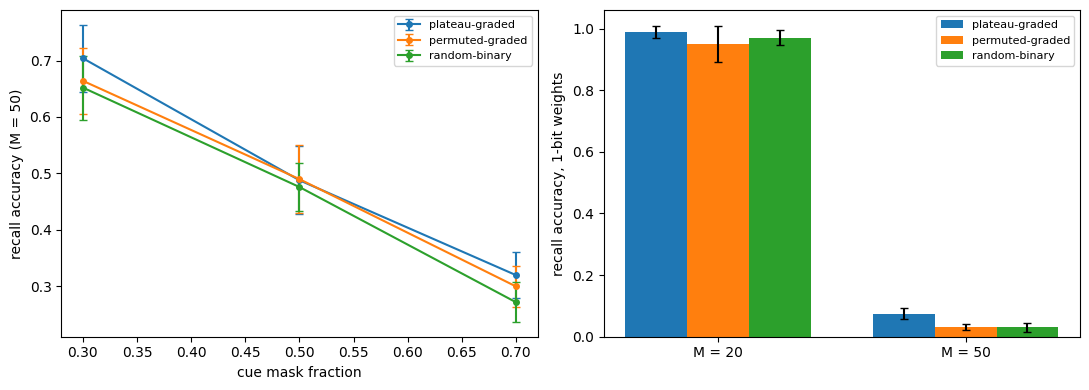

binary weights: one-shot storage works at M=20 with 1-bit synapses; capacity cliff by M=50 (report as-is).


In [7]:
# ungated is skipped here (it is at floor); each rule swept at M = 50
MASK = {mf: {r: sweep([50], mask_frac=mf, rules=[r])[r][50] for r in RULES[:3]}
        for mf in [0.3, 0.5, 0.7]}
BINW = {M_: {r: sweep([M_], binary_w=True, rules=RULES[:3])[r][M_] for r in RULES[:3]} for M_ in [20, 50]}
json.dump({'mask': MASK, 'binary_w': BINW}, open(os.path.join(OUT, 'robustness.json'), 'w'), indent=2)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for r in RULES[:3]:
    ax[0].errorbar([0.3, 0.5, 0.7], [np.mean(MASK[mf][r]) for mf in [0.3, 0.5, 0.7]],
                   yerr=[np.std(MASK[mf][r]) for mf in [0.3, 0.5, 0.7]], marker='o', ms=4, capsize=3, label=r)
ax[0].set_xlabel('cue mask fraction'); ax[0].set_ylabel('recall accuracy (M = 50)'); ax[0].legend(fontsize=8)
w = 0.25
for i, r in enumerate(RULES[:3]):
    ax[1].bar([x + (i - 1) * w for x in [0, 1]], [np.mean(BINW[M_][r]) for M_ in [20, 50]],
              width=w, yerr=[np.std(BINW[M_][r]) for M_ in [20, 50]], capsize=3, label=r)
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(['M = 20', 'M = 50'])
ax[1].set_ylabel('recall accuracy, 1-bit weights'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'fig_robustness.png'), dpi=200); plt.show()
print('binary weights: one-shot storage works at M=20 with 1-bit synapses; capacity cliff by M=50 (report as-is).')

## Summary for the manuscript
The summary cell below prints, with statistics, exactly the sentences Section 7.4 can carry. The pre-registered reading applies: the gate-vs-ungated result is the headline; content-addressability (plateau > permuted) is claimed only if its test is significant.

In [8]:
hl = np.mean(pool['plateau-graded']) - np.mean(pool['ungated'])
print(f"HEADLINE: plateau gating enables one-shot memorization; pooled advantage over the ungated rule "
      f"{hl:+.3f} recall (p = {tests['plateau-graded > ungated']['p_one_sided']:.4f}).")
pc = tests['plateau-graded > permuted-graded']
print(f"CONTENT-ADDRESSABILITY: plateau vs permuted-graded diff {pc['mean_diff']:+.3f}, p = {pc['p_one_sided']:.4f} -> "
      + ('CLAIM (significant)' if pc['p_one_sided'] < 0.05 else 'DO NOT CLAIM as significant; report the ordering descriptively'))
print('All artifacts saved to:', OUT)

HEADLINE: plateau gating enables one-shot memorization; pooled advantage over the ungated rule +0.439 recall (p = 0.0010).
CONTENT-ADDRESSABILITY: plateau vs permuted-graded diff -0.000, p = 0.1719 -> DO NOT CLAIM as significant; report the ordering descriptively
All artifacts saved to: /content/drive/My Drive/PG_LIF/P3_results/one_shot_v2
